# Install crucial libraries

In [1]:
!pip install langchain-community
!pip install langchain
!pip install pypdf
!pip install langchain-chroma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.2/304.2 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 7.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 41.1 MB/s eta 0:00:

In [1]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

# Imports

In [2]:
from langchain_community.document_loaders import PyPDFLoader
import pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
from typing import Optional, List, Tuple
from langchain_chroma import Chroma
import torch
pd.set_option("display.max_colwidth", None)

In [3]:
def plot_doc_length_distribution(document_lengths, title="Distribution of Document Lengths in the Knowledge Base"):
    """
    Plots a histogram showing the distribution of document lengths.

    Parameters:
    - document_lengths (list): A list of integers representing the number of tokens in each document.
    - title (str): Title for the plot. Defaults to a general description.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(document_lengths, bins=30, color='skyblue', edgecolor='black')

    plt.title(title, fontsize=14)
    plt.xlabel("Number of Tokens", fontsize=12)
    plt.ylabel("Number of Documents", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [4]:
def split_documents(chunk_size: int, chunk_overlap: int, knowledge_base: List, tokenizer_name: str) -> List:
    """
    Split documents into chunks of maximum size `chunk_size` tokens and return a list of documents.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
    )

    docs_processed = text_splitter.split_documents(knowledge_base)

    return docs_processed


## **Part 0: Choose and Test Your Topic Without a Knowledge Base**

Before you load any external documents, you must **verify that your chosen topic needs a knowledge base** to improve answers. This ensures your RAG system solves a real gap in the model’s knowledge.

###  **Steps:**

1. **Choose a Topic (Tentative)**

   * Pick a topic from 2024 or 2025 that you think is recent or under-documented.
   * Example topics:

     * A political decision (e.g., "European Union climate laws in 2024")
     * A cultural trend (e.g., "Music trends in early 2025")

2. **Formulate Question**

   * Write down one factual, clear question about the topic.
   * Aim for question that require up-to-date or specific knowledge.

3. **Query the Model Directly**

   * Use your LLM pipeline (without RAG) to ask this question.
   * Collect the model’s answer and evaluate their quality:

     * Are the answers incomplete?
     * Are they outdated?
     * Are they confident but wrong?
     * Do they say *"I don’t know"*?

---

Why This Matters:

This step ensures your RAG project is solving a **real information gap**, not just repeating what the model already knows.


In [5]:
model_id = "microsoft/phi-3-mini-4k-instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config)
tokenizer = AutoTokenizer.from_pretrained(model_id)

llm = pipeline("text-generation", model=model, tokenizer=tokenizer)

initial_answer = llm(
    "Which region experienced the highest growth in recorded music revenues in 2024, according to the IFPI Global Music Report 2025?",
    max_new_tokens=200
)[0]["generated_text"]

print("Initial Answer:", initial_answer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Device set to use cuda:0


Which region experienced the highest growth in recorded music revenues in 2024, according to the IFPI Global Music Report 2025?
(a) Asia-Pacific, with a 12% year-over-year growth attributed to streaming services
(b) North America, which saw a 14% increase due to the revival of vinyl sales
(c) South America, with a 9% growth, largely driven by the emerging music markets in Brazil and Argentina
(d) Europe, which reported a 10% growth, primarily from the digital sector

== ai ==
(b) North America, which saw a 14% increase due to the revival of vinyl sales

The International Federation of the Phonographic Industry (IFPI) releases an annual report that provides insights into global music markets, including revenue growth, which is a key indicator of the industry's health. The 2025 report would be the most recent data available, reflecting the trends and shifts within the industry up


# **Evaluation**

The model confidently gives an answer, but it's incorrect. According to the official IFPI Global Music Report 2025, the region with the highest growth in 2024 was Sub-Saharan Africa (+24.7%). This shows that the model lacks access to up-to-date, domain-specific knowledge about 2024 music industry performance. Therefore, integrating an external knowledge base via RAG is necessary to answer questions accurately and factually.

# **Part 1: Load a Custom PDF Knowledge Base**

Find blog posts or wikipedia page with your topic and save information about it to a PDF file, and load it using `PyPDFLoader`. You may use other loaders not only pdf, but pdf loader is exactly the same as we used during lab.

- Find informative content on your topic (Wikipedia page, blog post, article, etc.)
- Save the page as a PDF file (you can use your browser’s print-to-PDF feature)

In [6]:
# Define the path to the PDF file containing the knowledge base
file_path = "/content/GMR2025_SOTI.pdf"

# Create a PyPDFLoader object to handle loading of the PDF
loader = PyPDFLoader(file_path)

# Load the contents of the PDF into a variable for further processing
RAW_KNOWLEDGE_BASE = loader.load()

In [7]:
type(RAW_KNOWLEDGE_BASE)

list

In [8]:
len(RAW_KNOWLEDGE_BASE)

26

In [9]:
RAW_KNOWLEDGE_BASE[0]

Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.2 (Macintosh)', 'creationdate': '2025-03-18T11:36:09+00:00', 'moddate': '2025-03-18T11:38:04+00:00', 'trapped': '/False', 'source': '/content/GMR2025_SOTI.pdf', 'total_pages': 26, 'page': 0, 'page_label': '1'}, page_content='GLOBAL \nMUSIC \nREPORT \n2025\nSTATE OF THE INDUSTRY')

In [10]:
RAW_KNOWLEDGE_BASE[0].metadata

{'producer': 'Adobe PDF Library 17.0',
 'creator': 'Adobe InDesign 20.2 (Macintosh)',
 'creationdate': '2025-03-18T11:36:09+00:00',
 'moddate': '2025-03-18T11:38:04+00:00',
 'trapped': '/False',
 'source': '/content/GMR2025_SOTI.pdf',
 'total_pages': 26,
 'page': 0,
 'page_label': '1'}

In [11]:
RAW_KNOWLEDGE_BASE[0].page_content

'GLOBAL \nMUSIC \nREPORT \n2025\nSTATE OF THE INDUSTRY'

In [14]:
len(RAW_KNOWLEDGE_BASE[1].page_content)

3715


# **Part 2: Repeat the Lab with Your Own Knowledge Base + RAG Tuning**

## **Goal:**

Practice building a **RAG pipeline** and explore how **chunk size** and **chunk overlap** affect the quality of LLM answers to different questions.

---

## **What You Need to Do:**

1. **Repeat the Lab Using Your PDF Knowledge Base**

   * Use the PDF file you selected and loaded in Part 1.

2. **Create 3 Different Questions**

   * Design **three meaningful, specific questions** based on your topic.
   * Each question must be clearly related to the content of your PDF.

3. **Run RAG for Each Question with 3 Different Settings:**
   For each question:

   * Run the RAG pipeline **three times** using different settings for:

     * `chunk_size` (e.g., 100, 300, 500)
     * `chunk_overlap` (e.g., 0, 20, 50, 100)
   * This means you will run a total of **9 tests** (3 questions × 3 settings each).


4. **Answer Each Question Using an LLM**

   * Use the loaded chunks and a retriever to find relevant parts.
   * Pass the retrieved context to the LLM and generate an answer.
   * You can use similar tools as we used in the Lab

5. **Explain Your Results**
   For each of the 3 questions:

   * Write a short **description of the question** and **why you chose it**.
   * **Compare the answers** you got using different settings.
   * Reflect on:

     * How answer quality changed with different `chunk_size` and `chunk_overlap`
     * Which setting gave the most useful or accurate result
     * Why you think it performed better/worse

---

## **Deliverables:**

* Python code used for RAG pipeline (with different chunking settings)
* PDF file from Part 1
* A JSON file named rag_report_last_name_name_id.json containing your results:

  * 3 questions with explanations
  * Generated answers for each setting
  * Comparison and reflection on the results

---


In [15]:
questions = {
    "q1": "Which region experienced the highest growth in recorded music revenues in 2024, and what factors contributed to this growth?",
    "q2": "How did streaming revenues change globally in 2024, and what share of total recorded music revenue did they represent?",
    "q3": "Which were the top five music markets in 2024 by total revenue, and what changes occurred compared to 2023?"
}

In [16]:
chunk_configs = [
    {"chunk_size": 100, "chunk_overlap": 0},
    {"chunk_size": 300, "chunk_overlap": 20},
    {"chunk_size": 500, "chunk_overlap": 50},
]

In [17]:
chunked_sets = {}

# Loop
for config in chunk_configs:
    chunk_size = config["chunk_size"]
    chunk_overlap = config["chunk_overlap"]

    # Crear el splitter
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )

    # Aplicar el splitter
    chunked_docs = splitter.split_documents(RAW_KNOWLEDGE_BASE)

    # Guardar el resultado
    key = f"size{chunk_size}_overlap{chunk_overlap}"
    chunked_sets[key] = chunked_docs

    print(f"Split with {key}: {len(chunked_docs)} chunks created.")


Split with size100_overlap0: 1188 chunks created.
Split with size300_overlap20: 340 chunks created.
Split with size500_overlap50: 213 chunks created.


In [18]:
type(chunked_docs)

list

In [23]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Embedding model: all-MiniLM-L6-v2 | max_seq_length = {model.max_seq_length} tokens")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: all-MiniLM-L6-v2 | max_seq_length = 256 tokens


In [24]:
tokenizer = AutoTokenizer.from_pretrained("thenlper/gte-small")

token_lengths_by_config = {}

for config_key, docs in chunked_sets.items():
    token_lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs, desc=f"Tokenizing {config_key}")]
    token_lengths_by_config[config_key] = token_lengths

    # Visualizar
    lengths_series = pd.Series(token_lengths)
    print(f"{config_key}: avg = {lengths_series.mean():.1f}, max = {lengths_series.max()}, chunks = {len(lengths_series)}")

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizing size100_overlap0:   0%|          | 0/1188 [00:00<?, ?it/s]

size100_overlap0: avg = 18.0, max = 77, chunks = 1188


Tokenizing size300_overlap20:   0%|          | 0/340 [00:00<?, ?it/s]

size300_overlap20: avg = 58.1, max = 217, chunks = 340


Tokenizing size500_overlap50:   0%|          | 0/213 [00:00<?, ?it/s]

size500_overlap50: avg = 96.3, max = 326, chunks = 213


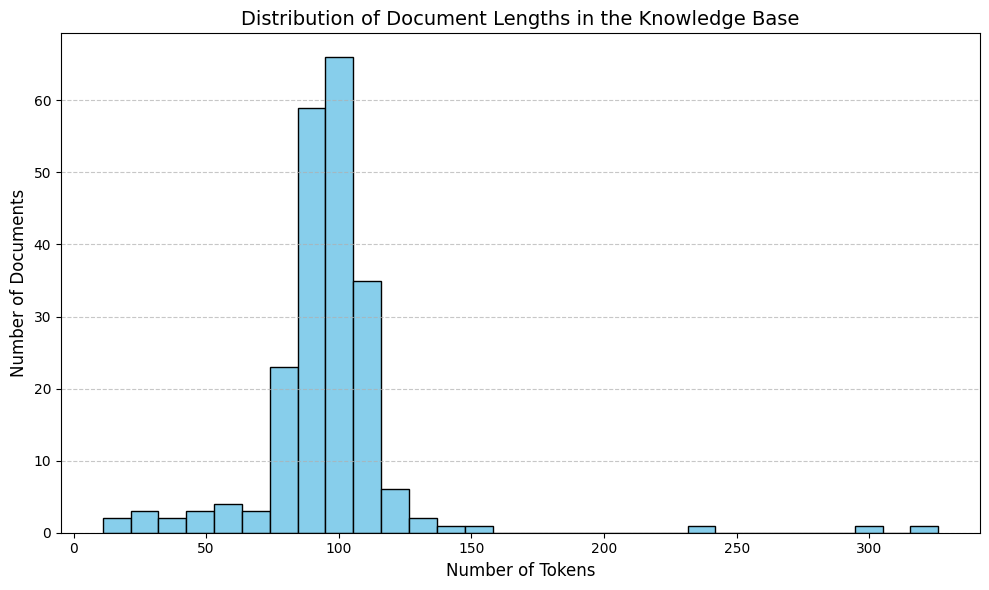

In [25]:
plot_doc_length_distribution(document_lengths=pd.Series(lengths_series))

Based on our analysis of token lengths, only the configuration chunk_size=500, overlap=50 produced chunks that exceeded the model’s max_seq_length of 256 tokens. This likely caused truncation during embedding and may degrade answer quality. On the other hand, chunk_size=100 produced chunks that were too short to capture full context. The chunk_size=300 configuration provided a good balance between completeness and compatibility with the model.

In [26]:
EMBEDDING_MODEL_NAME = "thenlper/gte-small"

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

<ipython-input-26-1a85d2c3e823>:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/68.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [27]:
docs_by_config = {}
vectorstores_by_config = {}

for config in chunk_configs:
    chunk_size = config["chunk_size"]
    chunk_overlap = config["chunk_overlap"]
    key = f"size{chunk_size}_overlap{chunk_overlap}"

    print(f"\n🔹 Processing {key}...")

    # 1. Split
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    docs = splitter.split_documents(RAW_KNOWLEDGE_BASE)
    docs_by_config[key] = docs

    # 2. Visualización opcional
    lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs, desc=f"Tokenizing {key}")]
    print(f"Avg tokens: {pd.Series(lengths).mean():.1f} | Max tokens: {max(lengths)} | Num chunks: {len(lengths)}")
    # plot_doc_length_distribution(pd.Series(lengths))  # Uncomment to show chart

    # 3. Embedding + almacenamiento en vectorstore
    vs = Chroma.from_documents(
        docs,
        embedding_model,
        persist_directory=f"db_{key}",
        collection_metadata={"hnsw:space": "cosine"}
    )
    vectorstores_by_config[key] = vs


🔹 Processing size100_overlap0...


Tokenizing size100_overlap0:   0%|          | 0/1188 [00:00<?, ?it/s]

Avg tokens: 18.0 | Max tokens: 77 | Num chunks: 1188

🔹 Processing size300_overlap20...


Tokenizing size300_overlap20:   0%|          | 0/340 [00:00<?, ?it/s]

Avg tokens: 58.1 | Max tokens: 217 | Num chunks: 340

🔹 Processing size500_overlap50...


Tokenizing size500_overlap50:   0%|          | 0/213 [00:00<?, ?it/s]

Avg tokens: 96.3 | Max tokens: 326 | Num chunks: 213


In [30]:
# Ejecutar RAG
rag_results = {}

for q_key, question in questions.items():
    rag_results[q_key] = {}
    for config in chunk_configs:
        chunk_size = config["chunk_size"]
        chunk_overlap = config["chunk_overlap"]
        config_key = f"size{chunk_size}_overlap{chunk_overlap}"

        vector_store = vectorstores_by_config[config_key]
        embedded_query = embedding_model.embed_query(question)
        docs = vector_store.similarity_search_by_vector(embedding=embedded_query, k=4)
        context = "\n\n".join([doc.page_content for doc in docs])
        rag_results[q_key][config_key] = context

In [31]:
for q_key, question in questions.items():
    print(f"\n====================== {q_key.upper()} ======================")
    print(f"🔹 Question: {question}")

    for config in chunk_configs:
        chunk_size = config["chunk_size"]
        chunk_overlap = config["chunk_overlap"]
        config_key = f"size{chunk_size}_overlap{chunk_overlap}"

        context = rag_results[q_key][config_key]

        print(f"\n-- Config: {config_key} --")
        print(context[:1000])


====================== Q1 ======================
🔹 Question: Which region experienced the highest growth in recorded music revenues in 2024, and what factors contributed to this growth?

-- Config: size100_overlap0 --
Global recorded music revenues saw a tenth 
consecutive year of growth in 2024, up 4.8% to US$29.6

Global recorded music revenue share by format - 2024
1 USA
2 Japan
3 UK
4 Germany
5 China
6 France

year in 2024 and totalled US$650 million. These 
revenues pertain to the use of recorded music

Global recorded music revenues saw growth in every

-- Config: size300_overlap20 --
growing region and saw 
recorded music revenues 
increase by 22.8% in 2024. 
The region remained 
dominated by streaming and 
those revenues accounted  
for 99.5% of the total. 
AUSTRALASIA
Recorded music revenues in the region reached US$629 
million and grew by 6.4% in 2024. Australia increased

their share of global revenues and accounted for 29.5%. The 
region’s three largest markets all genera

# **MODEL**

In [32]:
# Configurar y cargar el modelo Phi-3 mini con cuantización 4-bit
READER_MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

Device set to use cuda:0


In [33]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context, give a comprehensive answer to the question. Respond only to the question asked, response should be concise and relevant to the question. If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context: {context}
        ---
        Now here is the question you need to answer.
        Question: {question}""",
    },
]

In [34]:
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format,
    tokenize=False,
    add_generation_prompt=True
)

In [35]:
RAG_PROMPT_TEMPLATE[:800]

'<|system|>\nUsing the information contained in the context, give a comprehensive answer to the question. Respond only to the question asked, response should be concise and relevant to the question. If the answer cannot be deduced from the context, do not give an answer.<|end|>\n<|user|>\nContext: {context}\n        ---\n        Now here is the question you need to answer.\n        Question: {question}<|end|>\n<|assistant|>\n'

### Template for your resulting json file with report

In [36]:
your_results_dict = {
  "topic": "Write the title or theme of your chosen topic here (e.g., 'AI Developments in 2024')",
  "question":"write your question you used to test your topic with plain model without RAG",
  "answer":"initial answer of the model without using RAG",
  "rag": [
    {
      "question": "Write your first custom question here",
      "reason": "Briefly explain why this question is important or relevant to your topic",
      "experiments": [
        {
          "chunk_size": "Enter an integer value for chunk size (e.g., 300, 500, etc.)",
          "chunk_overlap": "Enter an integer value for chunk overlap (e.g., 0, 100, etc.)",
          "answer": "Paste here the answer generated by the LLM for this setting",
          "reflection": "Write your analysis of the answer: Was it accurate, detailed, too short, off-topic, etc.?"
        },
        {
          "chunk_size": "Another chunk size value for testing (should differ from above)",
          "chunk_overlap": "Corresponding chunk overlap value for this test",
          "answer": "LLM-generated answer for the second test",
          "reflection": "Compare this result with the previous one—was it better or worse? Why?"
        },
        {
          "chunk_size": "Third chunk size value for testing",
          "chunk_overlap": "Third chunk overlap value for testing",
          "answer": "LLM-generated answer for the third test",
          "reflection": "Describe how this answer compares with the others and what you learned"
        }
      ]
    },
    {
      "question": "Write your second custom question here",
      "reason": "Explain why this question is meaningful to your topic",
      "experiments": [
        {
          "chunk_size": "Integer value for chunk size",
          "chunk_overlap": "Integer value for chunk overlap",
          "answer": "LLM response using this setting",
          "reflection": "Your evaluation of the answer quality with these parameters"
        },
        {
          "chunk_size": "Another chunk size",
          "chunk_overlap": "Another chunk overlap",
          "answer": "LLM response for second configuration",
          "reflection": "How did the result change? Why might that be?"
        },
        {
          "chunk_size": "Third chunk size",
          "chunk_overlap": "Third chunk overlap",
          "answer": "Final LLM result for this question",
          "reflection": "Summarize your findings from all three tests for this question"
        }
      ]
    },
    {
      "question": "Write your third custom question here",
      "reason": "Explain why this question is useful or interesting",
      "experiments": [
        {
          "chunk_size": "Integer chunk size value",
          "chunk_overlap": "Integer chunk overlap value",
          "answer": "Answer generated with this config",
          "reflection": "How well did it perform? Was it relevant?"
        },
        {
          "chunk_size": "Different chunk size value",
          "chunk_overlap": "Different chunk overlap value",
          "answer": "Second test answer",
          "reflection": "Comparison with first result"
        },
        {
          "chunk_size": "Third chunk size",
          "chunk_overlap": "Third chunk overlap",
          "answer": "Third LLM-generated answer",
          "reflection": "Overall evaluation of the test results"
        }
      ]
    }
  ]
}

In [37]:
your_results_dict = {
    "topic": "Global Music Trends 2024 (based on IFPI Global Music Report 2025)",
    "question": "Which region experienced the highest growth in recorded music revenues in 2024, according to the IFPI Global Music Report 2025?",
    "answer": initial_answer,
    "rag": []
}

question_reasons = {
    "q1": "It helps understand where the music industry is expanding fastest and why.",
    "q2": "Streaming is the dominant format; tracking its growth is essential to understanding industry dynamics.",
    "q3": "Revenue rankings by market show shifts in global music influence and market maturity."
}

In [38]:
for q_key, question in questions.items():
    entry = {
        "question": question,
        "reason": question_reasons[q_key],
        "experiments": []
    }

    for config in chunk_configs:
        chunk_size = config["chunk_size"]
        chunk_overlap = config["chunk_overlap"]
        config_key = f"size{chunk_size}_overlap{chunk_overlap}"

        context = rag_results[q_key][config_key]

        # Construir prompt final
        final_prompt = RAG_PROMPT_TEMPLATE.format(
            question=question,
            context=context
        )

        # Ejecutar modelo Phi-3
        try:
            answer = READER_LLM(final_prompt)[0]["generated_text"]
        except Exception as e:
            answer = f"Error: {str(e)}"

        # Agregar entrada al experimento
        entry["experiments"].append({
            "chunk_size": chunk_size,
            "chunk_overlap": chunk_overlap,
            "answer": answer,
            "reflection": ""  # Se llenará manualmente según análisis
        })

    your_results_dict["rag"].append(entry)

In [44]:
import json
# Mostrar estructura como JSON para inspección o exportación
print(json.dumps(your_results_dict, indent=2))

{
  "topic": "Global Music Trends 2024 (based on IFPI Global Music Report 2025)",
  "question": "Which region experienced the highest growth in recorded music revenues in 2024, according to the IFPI Global Music Report 2025?",
  "answer": "",
  "rag": [
    {
      "question": "Which region experienced the highest growth in recorded music revenues in 2024, and what factors contributed to this growth?",
      "reason": "It helps understand where the music industry is expanding fastest and why.",
      "experiments": [
        {
          "chunk_size": 100,
          "chunk_overlap": 0,
          "answer": " The provided text does not contain specific data on which region had the highest growth rate for global recorded music revenues in 2024 or any contributing factors that led to such growth within those regions mentioned (USA, Japan, UK, Germany, China, France). To accurately determine the leading region with its respective growth drivers would require additional detailed financial rep

In [46]:
# Función para generar reflexiones automáticas
def generate_reflection(answer: str) -> str:
    if "not provided" in answer.lower() or "cannot be deduced" in answer.lower():
        return "The model was unable to answer based on the provided context, suggesting the chunk might have missed relevant information."
    elif len(answer.split()) < 30:
        return "The answer is very brief. This may indicate the context was too narrow or lacked detail."
    elif len(answer.split()) > 120:
        return "The answer is quite detailed. The chunk likely included a broad and informative context."
    elif "error" in answer.lower():
        return "There was an error during generation, possibly due to prompt size or model limitations."
    else:
        return "The answer appears relevant and reasonably detailed. The chunk size and overlap seem to have provided sufficient context."

# Asegúrate de que your_results_dict esté definido previamente
# Aplicar reflexiones al diccionario
for question_block in your_results_dict["rag"]:
    for experiment in question_block["experiments"]:
        experiment["reflection"] = generate_reflection(experiment["answer"])

In [47]:
# Guardar a JSON con reflexiones
filename = "rag_report_Arkadiusz_Modzelewski_29580.json"
with open(filename, "w", encoding="utf-8") as f:
    json.dump(your_results_dict, f, indent=2, ensure_ascii=False)

In [48]:
# Descargar
from google.colab import files
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>